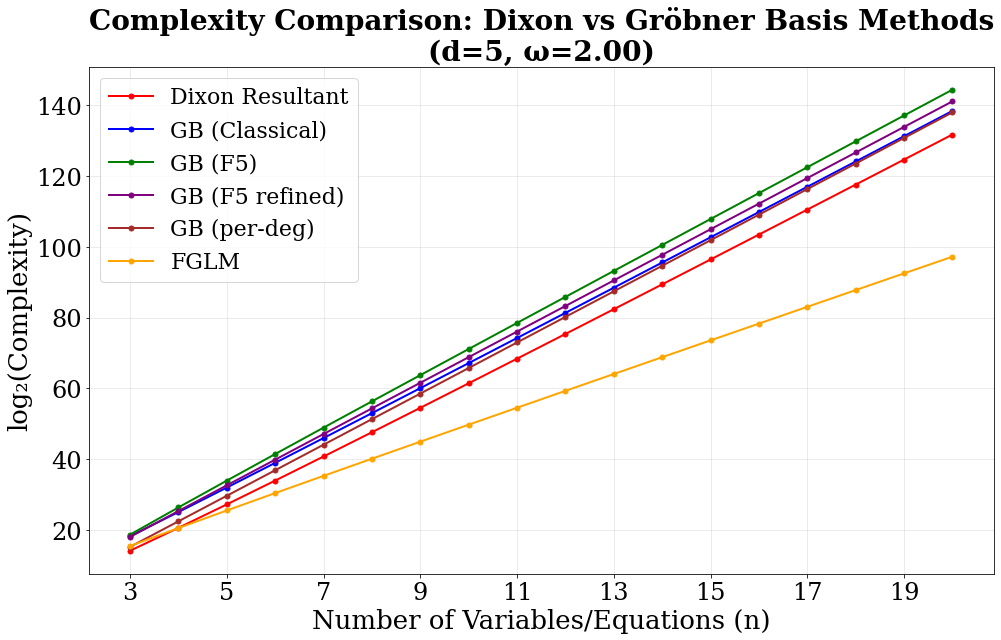


Complexity Comparison Table (log₂ scale)
Parameters: d=5, ω=2.00, k=0

   n |      Dixon Resultant |       GB (Classical) |              GB (F5) |      GB (F5 refined) |         GB (per-deg) |                 FGLM | 
---------------------------------------------------------------------------------------------------------------------------------------------------------------------
   3 |                14.17 |                18.26 |                18.71 |                18.08 |                15.27 |                15.52 | 
   4 |                20.63 |                25.09 |                26.40 |                25.38 |                22.48 |                20.58 | 
   5 |                27.25 |                32.01 |                33.97 |                32.64 |                29.69 |                25.54 | 
   6 |                33.98 |                38.98 |                41.47 |                39.89 |                36.90 |                30.45 | 
   7 |                40.78 |   

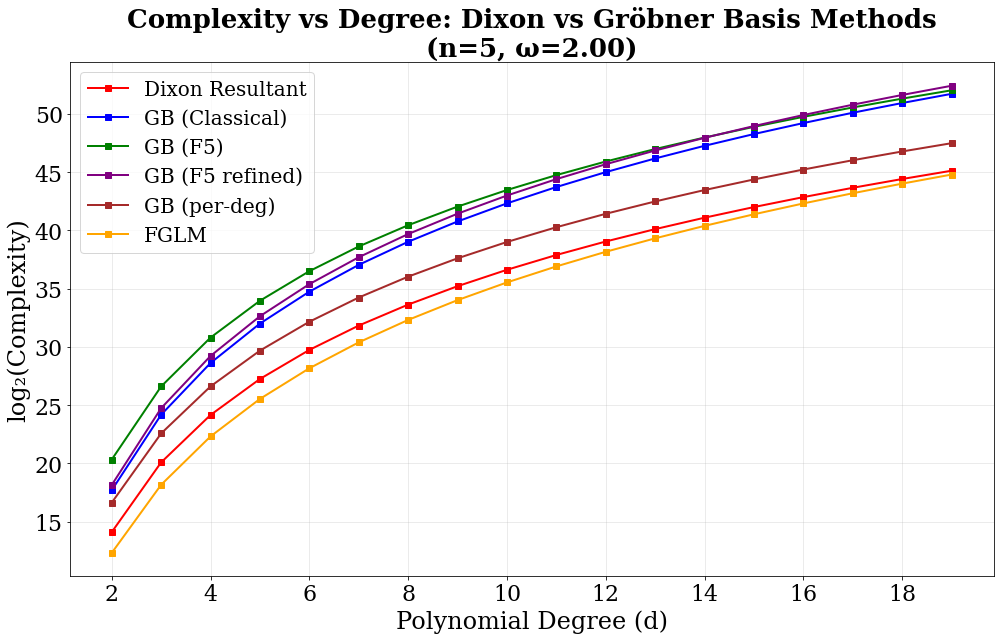


Complexity vs Degree Table (log₂ scale, n=5)

   d |      Dixon Resultant |       GB (Classical) |              GB (F5) |      GB (F5 refined) |         GB (per-deg) |                 FGLM | 
---------------------------------------------------------------------------------------------------------------------------------------------------------------------
   2 |                14.11 |                17.70 |                20.34 |                18.15 |                16.63 |                12.32 | 
   3 |                20.09 |                24.19 |                26.61 |                24.74 |                22.58 |                18.17 | 
   4 |                24.16 |                28.63 |                30.81 |                29.23 |                26.62 |                22.32 | 
   5 |                27.25 |                32.01 |                33.97 |                32.64 |                29.69 |                25.54 | 
   6 |                29.75 |                34.75 |     

In [1]:
# Complexity comparison: Dixon resultant vs Groebner basis methods.
#
# Figure / parameter map (see also OtherTools/complexity_figs.py, a pure-Python
# regenerator that writes the paper's file names directly):
#
#   Section 3.3, Figure 1  -> complexity_comparison_d2.png      d=2, omega=2.81
#   Appendix E, Figure 6a  -> complexity_comparison_d5.png      d=5, omega=2.81
#   Appendix E, Figure 6b  -> complexity_vs_degree_n3.png       n=3, omega=2.81
#   Appendix E, Figure 6c  -> complexity_vs_degree_n5.png       n=5, omega=2.81
#   Appendix E, Figure 6d  -> complexity_vs_degree_n5w237.png   n=5, omega=2.37
#                             (max-over-stages Dixon model, see comp_step1&4.ipynb)

from sage.all import *
import matplotlib.pyplot as plt
import numpy as np

# Set font to serif
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Georgia']
plt.rcParams['mathtext.fontset'] = 'cm'

# ==================== Parameter Settings ====================
omega = 2.81  # Linear algebra constant
n_values = range(3, 21)  # Range of number of variables/equations
d = 2  # Polynomial degree
k = 0  # Number of parameter variables retained (k=0 means well-defined system)

# ==================== 1. Dixon Resultant Complexity ====================

def fuss_catalan(n, d):
    """Fuss-Catalan number: C_n^(d) = 1/((d-1)n+1) * binom(dn, n)"""
    return binomial(d*n, n) / ((d-1)*n + 1)

def dixon_complexity(n, d, k, omega):
    """
    Dixon resultant complexity (from your paper)
    For (n;d)-systems with k=0 (well-defined systems):
    O(n*d * C_n^(d)^omega)
    """
    C_n_d = fuss_catalan(n, d)
    return n * d * C_n_d^omega

# ==================== 2. Gröbner Basis Complexity (Classical Upper Bound) ====================

def macaulay_bound(n, d):
    """Macaulay bound: d_reg <= 1 + n(d-1)"""
    return 1 + n*(d-1)

def gb_classical_complexity(n, d, omega):
    """
    (Classical) Gröbner basis complexity [Fau02]
    O(binom(n + d_reg, d_reg)^omega)
    """
    d_reg = macaulay_bound(n, d)
    return binomial(n + d_reg, d_reg)^omega

# ==================== 3. Refined Gröbner Basis Bounds ====================

def gb_reviewer_improved(n, d, omega):
    """
    GB (F5 refined): Macaulay matrix row echelon form [BFS15] with [Sto00],
    O(n_rows * n_cols * rank^(omega-2))
    
    For Macaulay matrix at degree d_reg = n(d-1)+1:
    - n_cols = binom(nd+1, n)
    - n_rows = n * binom(d(n-1)+1, n)
    - rank = binom(nd+1, n) - d^n
    """
    d_reg = macaulay_bound(n, d)
    n_cols = binomial(n*d + 1, n)
    n_rows = n * binomial(d*(n-1) + 1, n)
    rank = binomial(n*d + 1, n) - d^n
    
    return n_rows * n_cols * rank^(omega - 2)

def gb_bariant_formula(n, d, omega):
    """
    GB (F5) bound of [BFS15, BBLP22]:
    O(n * d_reg * binom(n + d_reg - 1, d_reg)^omega)
    """
    d_reg = macaulay_bound(n, d)
    return n * d_reg * binomial(n + d_reg - 1, d_reg)^omega

# ==================== 4. Bounds from (per-deg) Paper ====================

def gb_six_worlds_step1(n, d, omega):
    """
    GB complexity estimate from (per-deg) paper (Formula 6)
    Based on upper bound of solving degree
    """
    # Use Macaulay bound as upper bound for solving degree
    d_solv = macaulay_bound(n, d)
    
    complexity = 0
    for i in range(d_solv + 1):
        term1 = binomial(n + i - 1, i)^(omega - 1)
        term2 = sum(binomial(n + i - d - 1, i - d) for _ in range(n))
        complexity += term1 * term2
    
    return complexity

def fglm_six_worlds(n, d, omega):
    """
    FGLM complexity from (per-deg) paper (Formula 9)
    C_FGLM = n * d_I^omega
    """
    # Use (Classical) Bézout bound as upper bound for d_I
    d_I_bound = d^n  # (Classical) Bézout bound
    return n * d_I_bound^omega


def coo_hnf_complexity(n, d, omega):
    """
    Change of order by Hermite normal form [BNS22]:
        O~(t^(omega-1) * d_I)
    with the generic-system asymptotics of [BNS22, Tbl. 1] (from [FM17]):
        d_I = d^n,   t = d^(n-1)/sqrt(n).
    """
    t = d^(n-1) / sqrt(RealField(200)(n))
    return t^(omega - 1) * d^n


# ==================== 5. Compute All Complexities ====================

def compute_all_complexities(n, d, k, omega):
    """Compute all complexity upper bounds (log scale for comparison)"""
    results = {}
    
    # Dixon resultant
    results['Dixon Resultant'] = log(dixon_complexity(n, d, k, omega), 2).n()
    
    # Gröbner basis: (Classical) bound
    results['GB (Classical)'] = log(gb_classical_complexity(n, d, omega), 2).n()
    
    # Gröbner basis: (F5) bound
    #   n * d_reg * binom(n + d_reg - 1, d_reg)^omega
    results['GB (F5)'] = log(gb_bariant_formula(n, d, omega), 2).n()
    
    # Gröbner basis: (F5 refined) bound
    #   Macaulay row echelon form: n_rows * n_cols * rank^(omega - 2)
    try:
        results['GB (F5 refined)'] = log(gb_reviewer_improved(n, d, omega), 2).n()
    except:
        results['GB (F5 refined)'] = None
    
    # (per-deg): GB (Step 1)
    try:
        results['GB (per-deg)'] = log(gb_six_worlds_step1(n, d, omega), 2).n()
    except:
        results['GB (per-deg)'] = None
    
    # (per-deg): FGLM
    results['FGLM'] = log(fglm_six_worlds(n, d, omega), 2).n()
    
    # Change of order by Hermite normal form [BNS22]
    results['CoO (HNF)'] = log(coo_hnf_complexity(n, d, omega), 2).n()
    
    return results

# ==================== 6. Generate Data ====================

data = {method: [] for method in [
    'Dixon Resultant',
    'GB (Classical)', 
    'GB (F5)',
    'GB (F5 refined)',
    'GB (per-deg)',
    'FGLM',
]}

for n in n_values:
    results = compute_all_complexities(n, d, k, omega)
    for method, value in results.items():
        data[method].append(value)

# ==================== 7. Plot Line Chart ====================

plt.figure(figsize=(14, 9))

colors = {
    'Dixon Resultant': 'red',
    'GB (Classical)': 'blue',
    'GB (F5)': 'green',
    'GB (F5 refined)': 'purple',
    'GB (per-deg)': 'brown',
    'FGLM': 'orange',
    'CoO (HNF)': 'darkcyan',
}
'''
linestyles = {
    'Dixon Resultant': '-',
    'GB (Classical)': '--',
    'GB (F5)': '-.',
    'GB (F5 refined)': ':',
    'GB (per-deg)': '-',
    'FGLM': '--',
    'CoO (HNF)': '--',
}
'''
linestyles = {
    'Dixon Resultant': '-',
    'GB (Classical)': '-',
    'GB (F5)': '-',
    'GB (F5 refined)': '-',
    'GB (per-deg)': '-',
    'FGLM': '-',
    'CoO (HNF)': '-',
}

for method in data.keys():
    # Filter None values
    valid_data = [(n, v) for n, v in zip(n_values, data[method]) if v is not None]
    if valid_data:
        ns, vs = zip(*valid_data)
        plt.plot(ns, vs, 
                label=method, 
                color=colors[method],
                linestyle=linestyles[method],
                linewidth=2,
                marker='o',
                markersize=5)

# Set x-axis to show only integers
plt.xticks(range(min(n_values), max(n_values) + 1, 2))

plt.xlabel('Number of Variables/Equations (n)', fontsize=26)
plt.ylabel('log₂(Complexity)', fontsize=26)
plt.title(f'Complexity Comparison: Dixon vs Gröbner Basis Methods\n(d={d}, ω={omega:.2f})', fontsize=28, fontweight='bold')
plt.legend(loc='best', fontsize=22)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=24)
plt.tight_layout()

# Save figure
plt.savefig(f'complexity_comparison_d{d}.png', dpi=300, bbox_inches='tight')
plt.show()

# ==================== 8. Print Detailed Data Table ====================

print(f"\n{'='*100}")
print(f"Complexity Comparison Table (log₂ scale)")
print(f"Parameters: d={d}, ω={omega:.2f}, k={k}")
print(f"{'='*100}\n")

print(f"{'n':>4} | ", end='')
for method in data.keys():
    print(f"{method:>20} | ", end='')
print()
print('-'*165)

for i, n in enumerate(n_values):
    print(f"{n:>4} | ", end='')
    for method in data.keys():
        value = data[method][i]
        if value is not None:
            print(f"{value:>20.2f} | ", end='')
        else:
            print(f"{'N/A':>20} | ", end='')
    print()

# ==================== 9. Asymptotic Comparison Analysis ====================

print(f"\n{'='*100}")
print("Asymptotic Advantage Analysis")
print(f"{'='*100}\n")

# Select larger n value for comparison
n_test = 15

results_test = compute_all_complexities(n_test, d, k, omega)

print(f"At n={n_test}, d={d}, ω={omega:.2f}:")
print(f"  Dixon Resultant:        2^{results_test['Dixon Resultant']:.2f}")
print(f"  GB (Classical):           2^{results_test['GB (Classical)']:.2f}")
print(f"  GB (F5):                2^{results_test['GB (F5)']:.2f}")
print(f"  GB (F5 refined):         2^{results_test['GB (F5 refined)']:.2f}")
print(f"  GB (per-deg):          2^{results_test['GB (per-deg)']:.2f}")

print(f"\nComplexity Ratios (log₂ difference):")
print(f"  GB (Classical) / Dixon:   {results_test['GB (Classical)'] - results_test['Dixon Resultant']:.2f} bits")
print(f"  GB (F5) / Dixon:        {results_test['GB (F5)'] - results_test['Dixon Resultant']:.2f} bits")
print(f"  GB (F5 refined) / Dixon: {results_test['GB (F5 refined)'] - results_test['Dixon Resultant']:.2f} bits")
print(f"  GB (per-deg) / Dixon:  {results_test['GB (per-deg)'] - results_test['Dixon Resultant']:.2f} bits")
print(f"  FGLM / Dixon:  {results_test['FGLM'] - results_test['Dixon Resultant']:.2f} bits")
print(f"  CoO (HNF) / Dixon:  {results_test['CoO (HNF)'] - results_test['Dixon Resultant']:.2f} bits")

# ==================== 10. Comparison with Fixed n and Varying d ====================

n_fixed_d = 3  # Fixed number of variables
d_values = range(2, 20)  # Range of polynomial degrees
omega = 2.81
data_vs_d = {method: [] for method in [
    'Dixon Resultant',
    'GB (Classical)', 
    'GB (F5)',
    'GB (F5 refined)',
    'GB (per-deg)',
    'FGLM',
]}

print(f"\n{'='*100}")
print(f"Computing complexities for varying d (fixed n={n_fixed_d})...")
print(f"{'='*100}\n")

for d_val in d_values:
    results = compute_all_complexities(n_fixed_d, d_val, k, omega)
    for method, value in results.items():
        data_vs_d[method].append(value)

plt.figure(figsize=(14, 9))

for method in data_vs_d.keys():
    # Filter None values
    valid_data = [(d_val, v) for d_val, v in zip(d_values, data_vs_d[method]) if v is not None]
    if valid_data:
        ds, vs = zip(*valid_data)
        plt.plot(ds, vs, 
                label=method, 
                color=colors[method],
                linestyle=linestyles[method],
                linewidth=2,
                marker='s',
                markersize=6)

# Set x-axis to show only integers        
plt.xticks(range(min(d_values), max(d_values) + 1, 2))

plt.xlabel('Polynomial Degree (d)', fontsize=24)
plt.ylabel('log₂(Complexity)', fontsize=24)
plt.title(f'Complexity vs Degree: Dixon vs Gröbner Basis Methods\n(n={n_fixed_d}, ω={omega:.2f})', fontsize=26, fontweight='bold')
plt.legend(loc='best', fontsize=20)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=22)
plt.tight_layout()
plt.savefig(f'complexity_vs_degree_n{n_fixed_d}.png', dpi=300, bbox_inches='tight')
plt.show()

# Print data table for varying d
print(f"\n{'='*100}")
print(f"Complexity vs Degree Table (log₂ scale, n={n_fixed_d})")
print(f"{'='*100}\n")

print(f"{'d':>4} | ", end='')
for method in data_vs_d.keys():
    print(f"{method:>20} | ", end='')
print()
print('-'*165)

for i, d_val in enumerate(d_values):
    print(f"{d_val:>4} | ", end='')
    for method in data_vs_d.keys():
        value = data_vs_d[method][i]
        if value is not None:
            print(f"{value:>20.2f} | ", end='')
        else:
            print(f"{'N/A':>20} | ", end='')
    print()

print("\n✓ Analysis complete! Figures saved as:")
print(f"  - complexity_comparison_d{d}.png")
print(f"  - complexity_vs_degree_n{n_fixed_d}.png")